# MSc Data Science Final Project — University of Hertfordshire
## Bank Term Deposit Subscription Prediction
### A Comparative Performance Analysis of Machine Learning Models

**Module:** 7PAM2002 — Data Science Final Project  

---

### Part 1: Data Loading, Inspection & Exploratory Data Analysis (EDA)

This notebook covers Sections 3.1 to 3.2 of the final report:
- Loading and inspecting the Bank Marketing dataset
- Identifying duplicates, unknown values, and the pdays anomaly
- Summary statistics, class distribution, and feature distributions
- Correlation analysis and outlier detection

## Cell 1 — Import Libraries

In [2]:
# Loading all the tools this project depends on before anything else.
# These libraries handle data loading, manipulation, visualisation,
# and will also support the modelling work in later parts.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Show all columns and round floats to 2 decimal places for cleaner output
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Consistent visual style across every chart in this notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Project colour scheme — defined once and reused across all charts
COLOUR_NO  = '#378ADD'   # blue  — clients who did not subscribe
COLOUR_YES = '#D85A30'   # coral — clients who subscribed
PALETTE    = [COLOUR_NO, COLOUR_YES]

# Target column name defined once so it is easy to change if needed
TARGET = 'subscribed'

print('All libraries imported and settings configured successfully.')

All libraries imported and settings configured successfully.


## Cell 2 — Load the Dataset from GitHub

> The file uses a **semicolon** (`;`) as its separator, not a comma. Without `sep=';'` all 21 columns would collapse into one unusable column.

In [3]:
# Loading directly from GitHub means the notebook runs correctly
# from any machine without needing a local copy of the file.

URL = ('https://raw.githubusercontent.com/Nkengfack/Bank_marketing_ml_Classifications/refs/heads/main/bank_marketing_dataset.csv')

marketing = pd.read_csv(URL, sep=';')

# The original target column is called 'y' in the UCI dataset.
# Renaming it makes the code easier to follow throughout.
marketing.rename(columns={'y': TARGET}, inplace=True)

print(f'Dataset loaded successfully from GitHub.')
print(f'Rows     : {marketing.shape[0]:,}')
print(f'Columns  : {marketing.shape[1]}')
print(f'Features : {marketing.shape[1] - 1}  (excluding target column)')
print(f'Target   : {TARGET}  (yes = subscribed,  no = did not subscribe)')
print(f'\nColumn names:')
print(marketing.columns.tolist())

Dataset loaded successfully from GitHub.
Rows     : 41,188
Columns  : 21
Features : 20  (excluding target column)
Target   : subscribed  (yes = subscribed,  no = did not subscribe)

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


## Cell 3 — First Look at the Data

Always the first thing to run after loading — confirms the file loaded correctly and the values look sensible.

In [4]:
marketing.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


## Cell 4 — Data Types and Structure

Shows the data type of every column and how many non-null values exist. This is the first check for missing data.

In [5]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Cell 5 — Summary Statistics (Numerical Columns)

This output becomes **Figure 3.1** in the report. Pay attention to columns where max is far above the 75th percentile — that gap usually signals outliers.

In [6]:
print('Summary Statistics — Numerical Features (Figure 3.1)')
print('=' * 60)
marketing.describe()

Summary Statistics — Numerical Features (Figure 3.1)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


## Cell 6 — Summary Statistics (Categorical Columns)

`include='object'` extends describe() to text columns. The `top` row shows the most frequent value. Notice `unknown` appearing in several columns.

In [7]:
print('Summary Statistics — Categorical Features')
print('=' * 60)
marketing.describe(include='object')

Summary Statistics — Categorical Features


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


## Cell 7 — Detecting Hidden Missing Values

This dataset has no NaN values, which looks clean on the surface. However several columns use the string `unknown` as a placeholder which behaves exactly like a missing value but is invisible to `isnull()`.

In [8]:
print('Columns containing unknown values')
print('=' * 60)

unknown_summary = {}

for col in marketing.columns:
    if col == TARGET:
        continue
    try:
        count = (marketing[col] == 'unknown').sum()
        pct   = round(count / len(marketing) * 100, 2)
        if count > 0:
            unknown_summary[col] = {
                'Unknown Count' : count,
                'Unknown (%)'   : pct
            }
    except TypeError:
        continue

if unknown_summary:
    unknown_df = pd.DataFrame(unknown_summary).T
    print(unknown_df.to_string())
    print(f'\nTotal unknown entries across all columns: '
          f'{unknown_df["Unknown Count"].sum():,.0f}')
else:
    print('No columns contain the string "unknown".')

print('\nNote: default has the highest proportion at over 20%.')
print('These will be kept as a separate category during preprocessing')
print('rather than dropped, to avoid losing too many records.')

Columns containing unknown values
           Unknown Count  Unknown (%)
job               330.00         0.80
marital            80.00         0.19
education        1731.00         4.20
default          8597.00        20.87
housing           990.00         2.40
loan              990.00         2.40

Total unknown entries across all columns: 12,718

Note: default has the highest proportion at over 20%.
These will be kept as a separate category during preprocessing
rather than dropped, to avoid losing too many records.


## Cell 8 — Understanding the pdays and previous Columns

These two columns are closely related. Looking at their value counts reveals something important that is easy to miss from the dataset description alone.  

> **No changes are made to the DataFrame in this cell** — EDA is about understanding, not transforming. The actual transformation happens in Part 2.

In [9]:
print('Value counts — previous column')
print('=' * 45)
print(marketing['previous'].value_counts().sort_index())

print()
print('Value counts — pdays column (top 15)')
print('=' * 45)
print(marketing['pdays'].value_counts().head(15))

print()
print('Clients with previous = 0 (no prior contact) :',
      (marketing['previous'] == 0).sum())
print('Clients with pdays = 999 (date unknown)       :',
      (marketing['pdays'] == 999).sum())

# The key finding
print()
gap = (marketing['pdays'] == 999).sum() - (marketing['previous'] == 0).sum()
print(f'Gap between pdays=999 and previous=0 : {gap:,} clients')

print()
both = ((marketing['previous'] > 0) & (marketing['pdays'] == 999)).sum()
print(f'Clients with previous > 0 AND pdays = 999 : {both:,}')
print('These clients were contacted before but their last contact date')
print('was not recorded. This confirms 999 means date unknown,')
print('not never contacted.')

print()
print('Scenario breakdown')
print('-' * 60)
scenario_a = ((marketing['previous'] == 0) & (marketing['pdays'] == 999)).sum()
scenario_b = ((marketing['previous'] >  0) & (marketing['pdays'] == 999)).sum()
scenario_c = ((marketing['previous'] >  0) & (marketing['pdays'] != 999)).sum()
print(f'A  previous=0  pdays=999   Never contacted at all       : {scenario_a:,}')
print(f'B  previous>0  pdays=999   Contacted, date not recorded : {scenario_b:,}')
print(f'C  previous>0  pdays!=999  Contacted, date known        : {scenario_c:,}')

print()
print('No changes made to the DataFrame in this cell.')
print('pdays and previous will be transformed during preprocessing in Part 2.')
print(f'Current DataFrame shape: {marketing.shape}')

Value counts — previous column
previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

Value counts — pdays column (top 15)
pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
Name: count, dtype: int64

Clients with previous = 0 (no prior contact) : 35563
Clients with pdays = 999 (date unknown)       : 39673

Gap between pdays=999 and previous=0 : 4,110 clients

Clients with previous > 0 AND pdays = 999 : 4,110
These clients were contacted before but their last contact date
was not recorded. This confirms 999 means date unknown,
not never contacted.

Scenario breakdown
------------------------------------------------------------
A  previous=0  pdays=999   Never contacted at all       : 35,563
B  previous>0  pdays=999   Contacted, date not recorded : 4,110
C  previous>0  pd

## Cell 9 — Removing Duplicate Records

Duplicate rows skew distributions and bias model training. Removing them before producing EDA charts keeps everything accurate.

In [10]:
duplicates_found = marketing.duplicated().sum()
print(f'Duplicate rows found: {duplicates_found}')

marketing.drop_duplicates(keep='first', ignore_index=True, inplace=True)
print(f'Duplicates removed.')
print(f'Dataset now has {len(marketing):,} rows.')

Duplicate rows found: 12
Duplicates removed.
Dataset now has 41,176 rows.


## Cell 10 — Classify Columns by Type

Separating columns into numerical and categorical lists here once so they can be reused cleanly throughout the rest of the notebook.

In [11]:
num_features = marketing.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

cat_features = [
    col for col in
    marketing.select_dtypes(include='object').columns.tolist()
    if col != TARGET
]

print(f'Numerical features ({len(num_features)}):')
for col in num_features:
    print(f'  {col}')

print(f'\nCategorical features ({len(cat_features)}):')
for col in cat_features:
    print(f'  {col}')

print(f'\nTarget column: {TARGET}  (binary — yes / no)')

Numerical features (10):
  age
  duration
  campaign
  pdays
  previous
  emp.var.rate
  cons.price.idx
  cons.conf.idx
  euribor3m
  nr.employed

Categorical features (10):
  job
  marital
  education
  default
  housing
  loan
  contact
  month
  day_of_week
  poutcome

Target column: subscribed  (binary — yes / no)


## Cell 11 — Target Variable: Class Distribution (Figure 3.2)

The most important early finding in the entire EDA. The class imbalance visible here motivates SMOTE, the metric selection, and the pipeline design in Part 2.

Target Variable — Class Distribution
            Count  Percentage (%)
subscribed                       
no          36537           88.73
yes          4639           11.27


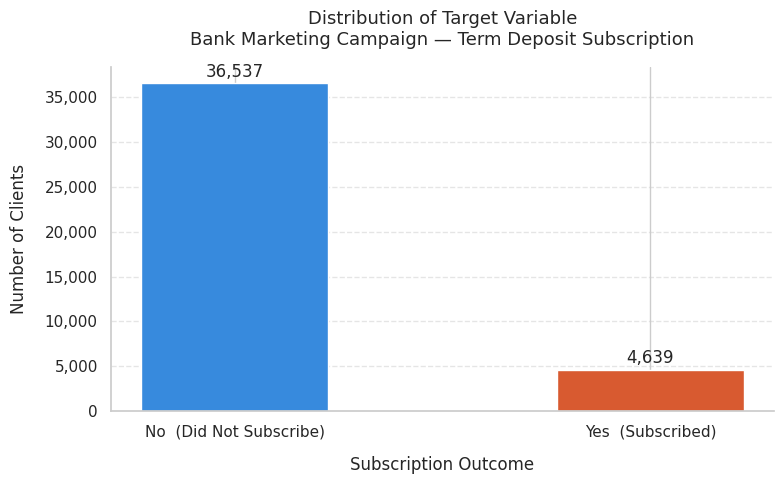


Class imbalance: 88.7% no  vs  11.3% yes
This imbalance will be addressed using SMOTE in Part 2.


In [12]:
counts = marketing[TARGET].value_counts()
pcts   = marketing[TARGET].value_counts(normalize=True) * 100

print('Target Variable — Class Distribution')
print('=' * 45)
print(pd.DataFrame({
    'Count'          : counts,
    'Percentage (%)' : pcts.round(2)
}))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ['No  (Did Not Subscribe)', 'Yes  (Subscribed)'],
    counts.values,
    color=PALETTE,
    width=0.45,
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 280,
        f'{bar.get_height():,}',
        ha='center', va='bottom',
        fontsize=12, fontweight='medium'
    )

plt.title(
    'Distribution of Target Variable\n'
    'Bank Marketing Campaign — Term Deposit Subscription',
    pad=16, fontsize=13
)
plt.xlabel('Subscription Outcome', labelpad=12)
plt.ylabel('Number of Clients', labelpad=12)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_3_2_class_distribution.png', dpi=300)
plt.show()

print(f"\nClass imbalance: {pcts['no']:.1f}% no  vs  {pcts['yes']:.1f}% yes")
print('This imbalance will be addressed using SMOTE in Part 2.')

## Cell 12 — Distribution of Numerical Features

A histogram with KDE curve for each numerical feature individually. Each chart is saved as its own PNG file for use in the report. The skewness annotation flags features that may need special handling during preprocessing.

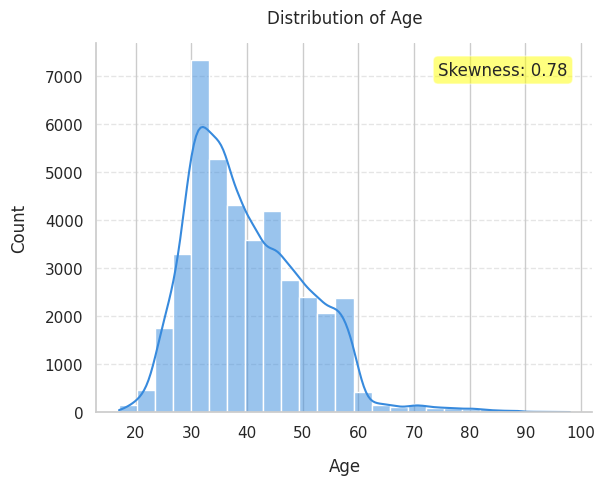

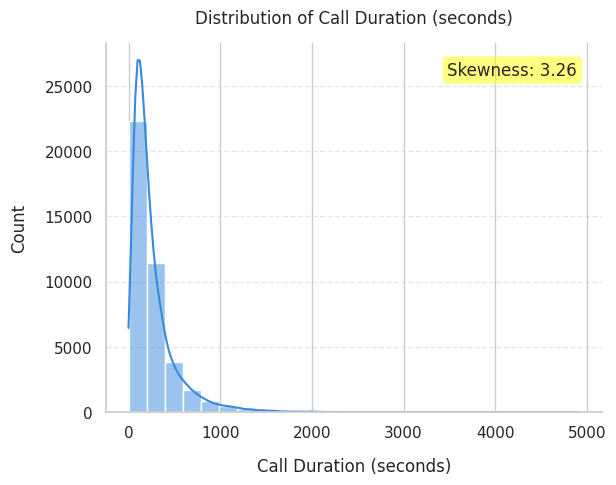

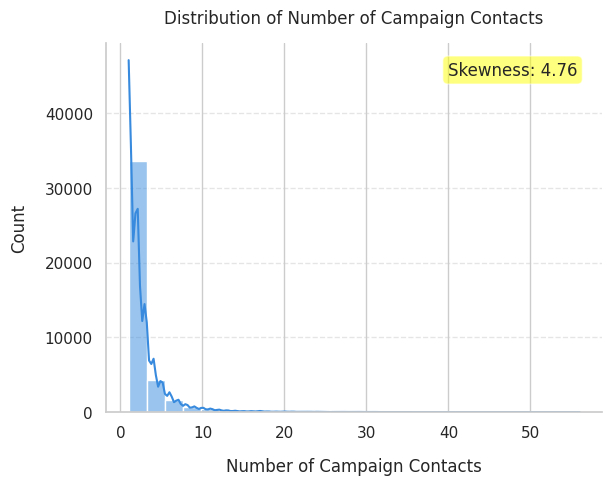

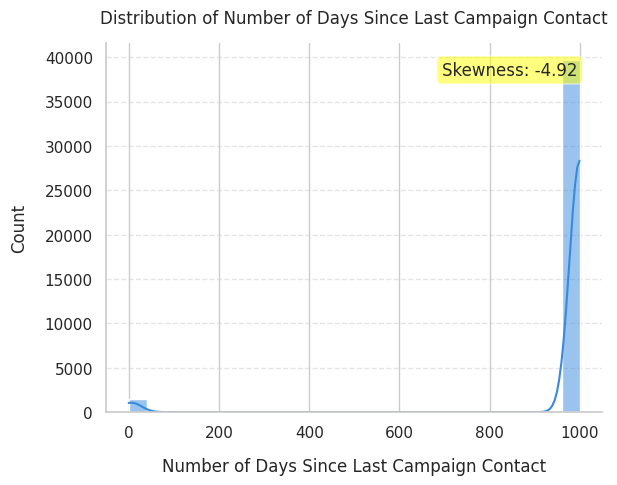

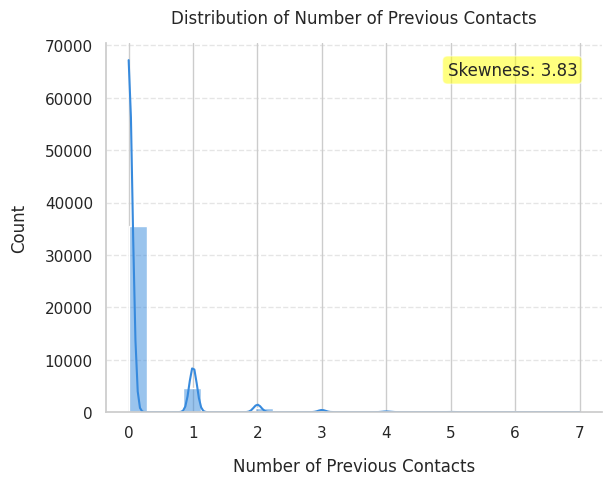

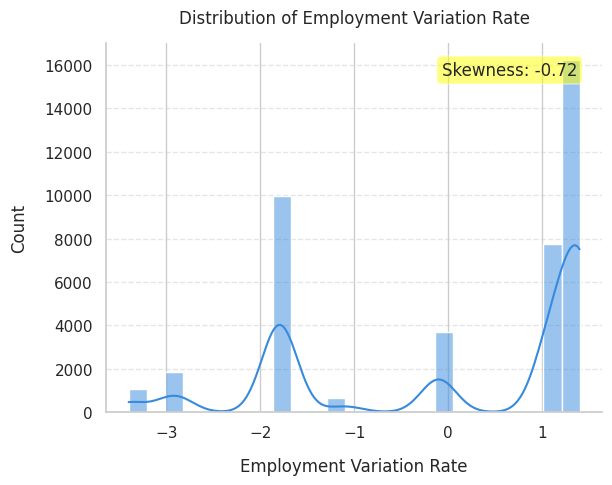

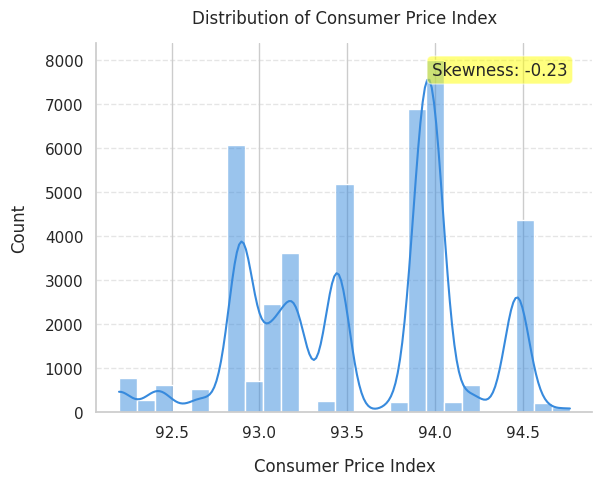

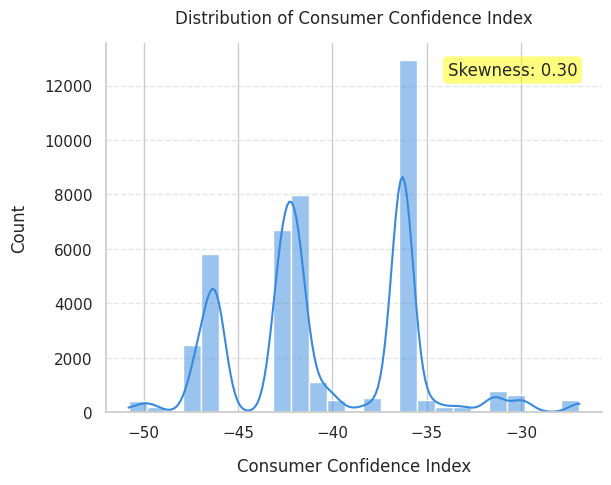

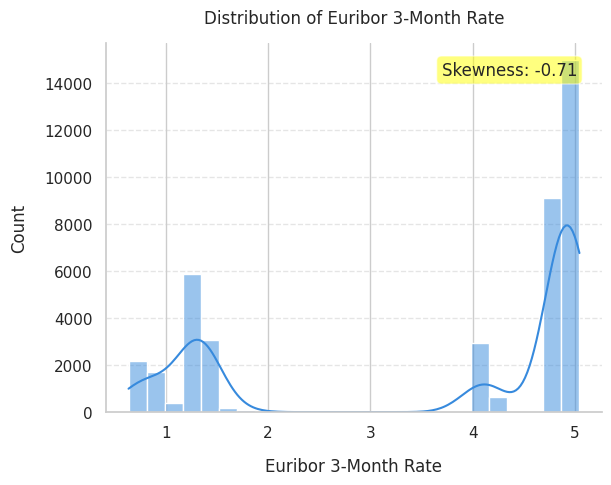

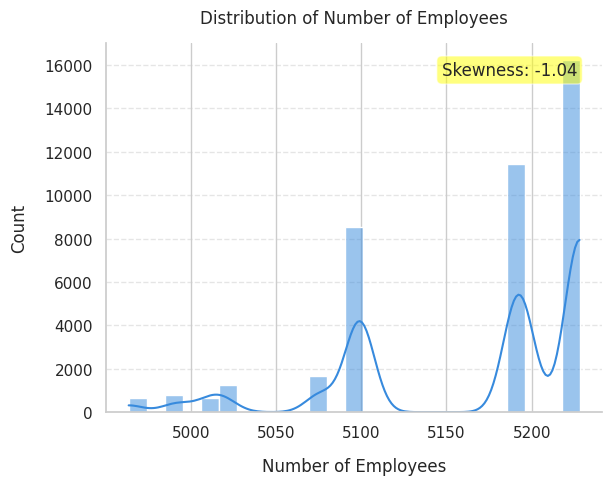

In [13]:
# Friendly display names for chart titles and filenames
feature_names = {
    'age'            : 'Age',
    'duration'       : 'Call Duration (seconds)',
    'campaign'       : 'Number of Campaign Contacts',
    'pdays'          : 'Number of Days Since Last Campaign Contact',
    'previous'       : 'Number of Previous Contacts',
    'emp.var.rate'   : 'Employment Variation Rate',
    'cons.price.idx' : 'Consumer Price Index',
    'cons.conf.idx'  : 'Consumer Confidence Index',
    'euribor3m'      : 'Euribor 3-Month Rate',
    'nr.employed'    : 'Number of Employees'
}

# Redefine here to reflect the current state of the DataFrame
num_features = marketing.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

for col in num_features:
    fig, ax = plt.subplots()

    sns.histplot(marketing[col], kde=True, bins=25, color=COLOUR_NO)

    # .get(col, col) falls back to the raw column name if not in dictionary
    plt.title(f'Distribution of {feature_names.get(col, col)}', pad=14)
    plt.text(
        0.95, 0.95,
        f'Skewness: {marketing[col].skew():.2f}',
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
    )
    plt.xlabel(feature_names.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.savefig(f'Distribution of {feature_names.get(col, col)}.png', dpi=300)
    plt.show()

    print('\n')

## Cell 13 — Distribution of Categorical Features

A count plot for each categorical feature individually, sorted from most to least frequent. Bars are labelled with counts for easy reading in the report.

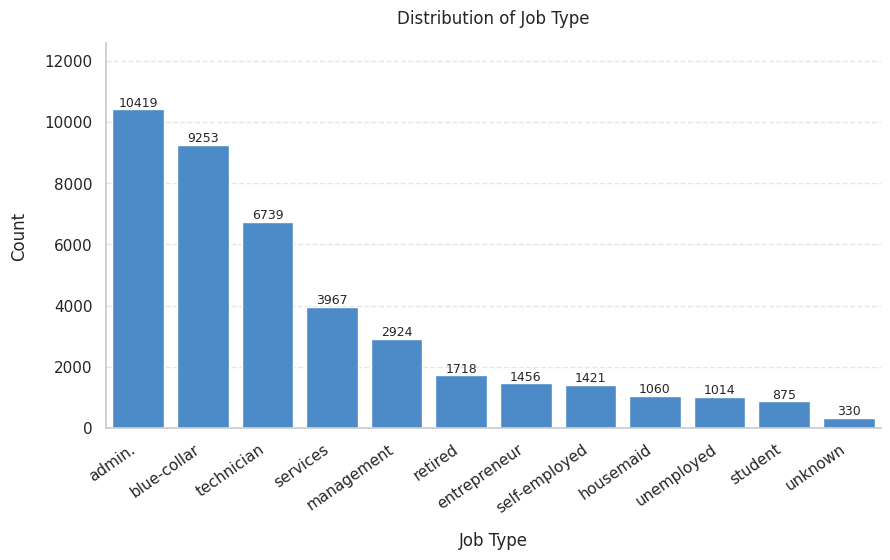

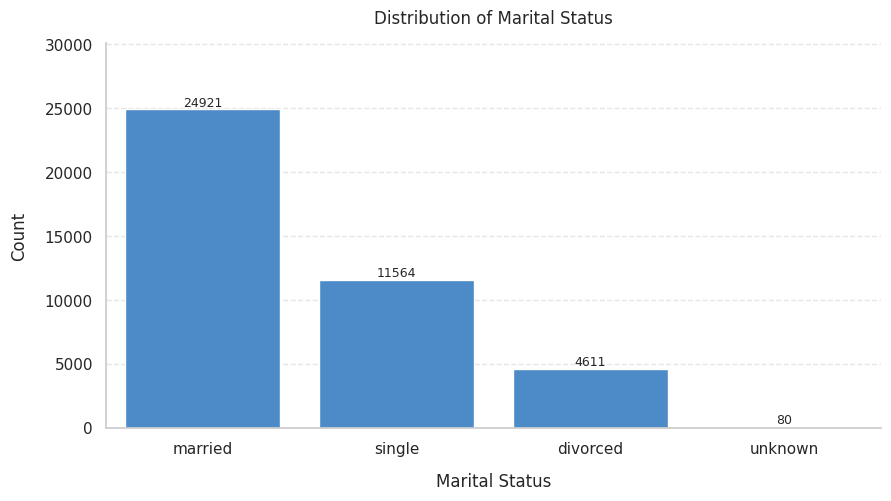

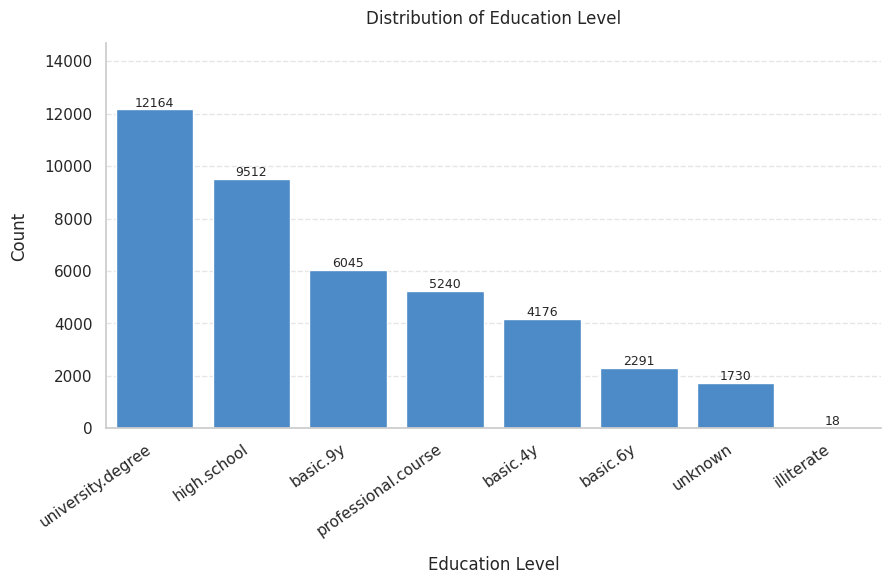

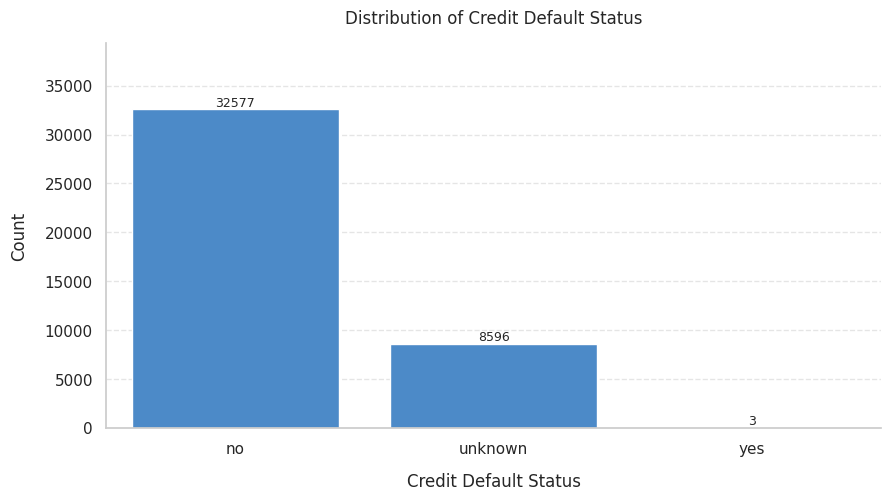

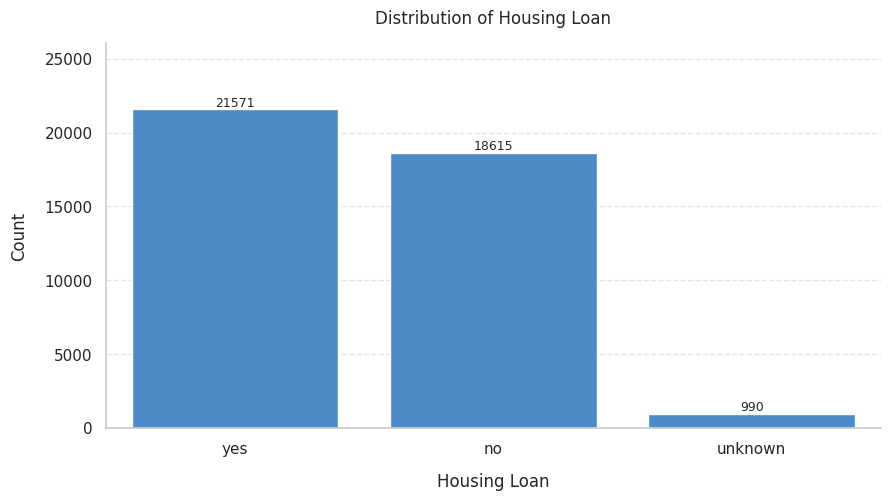

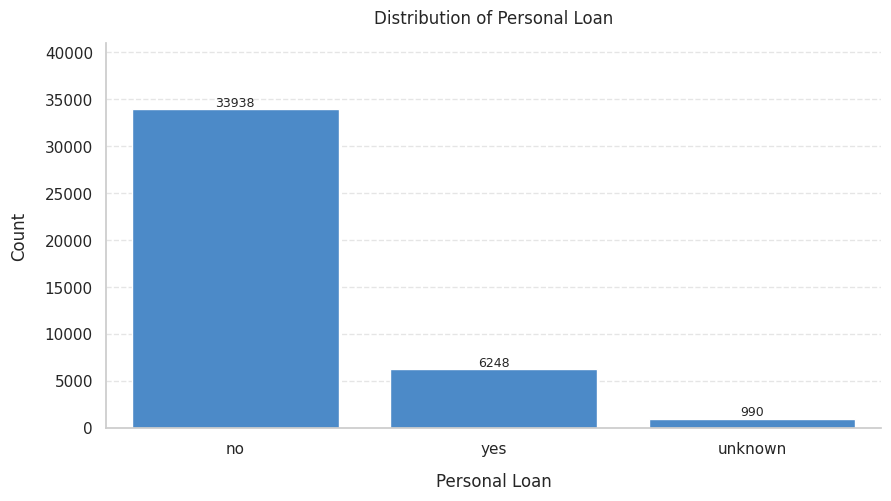

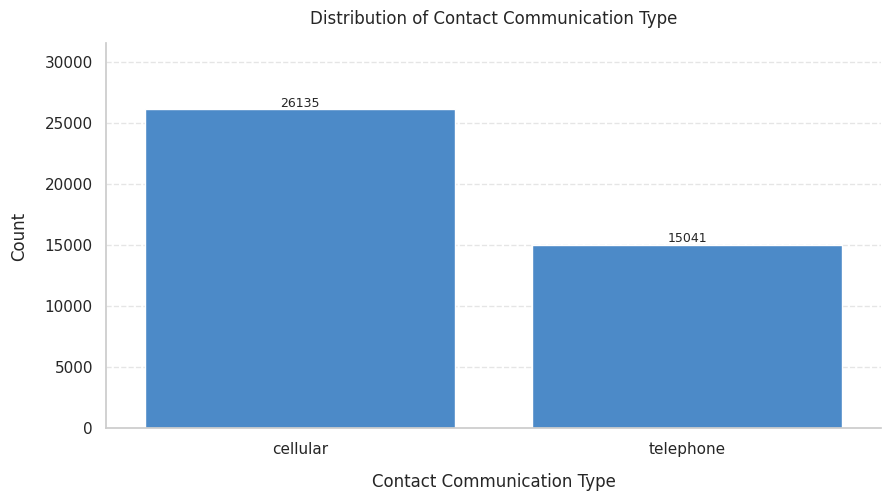

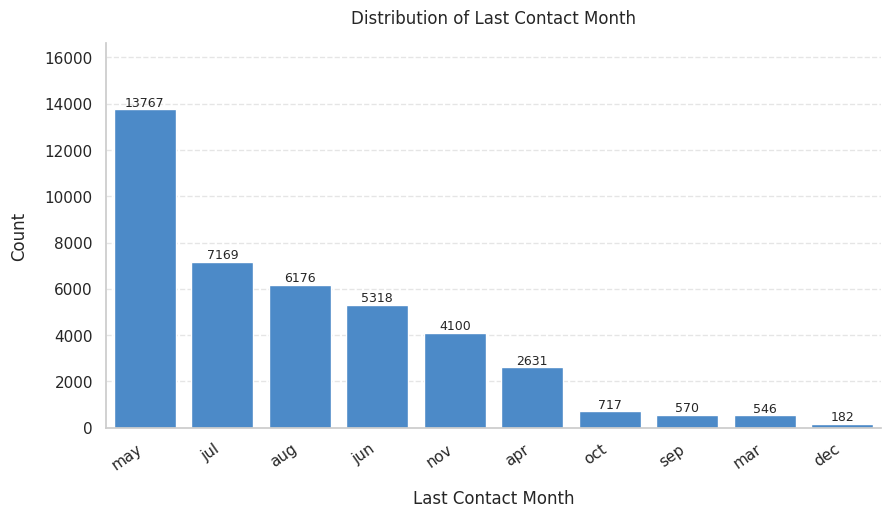

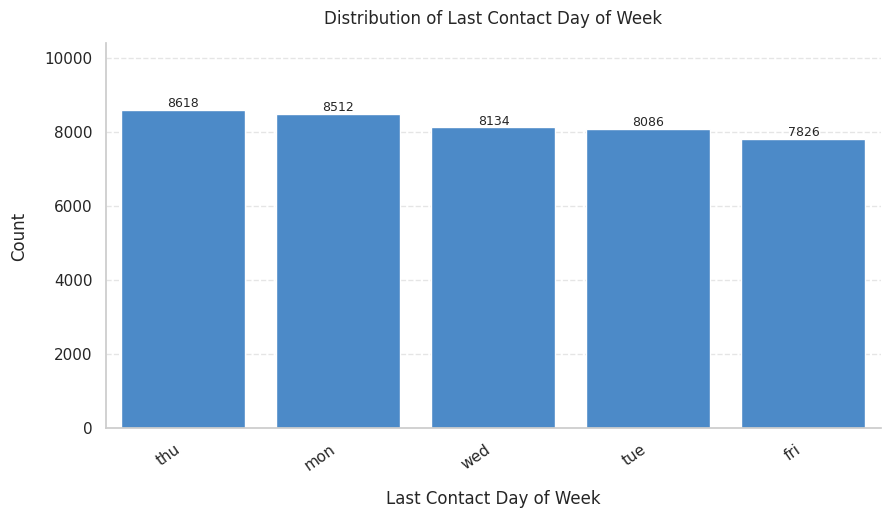

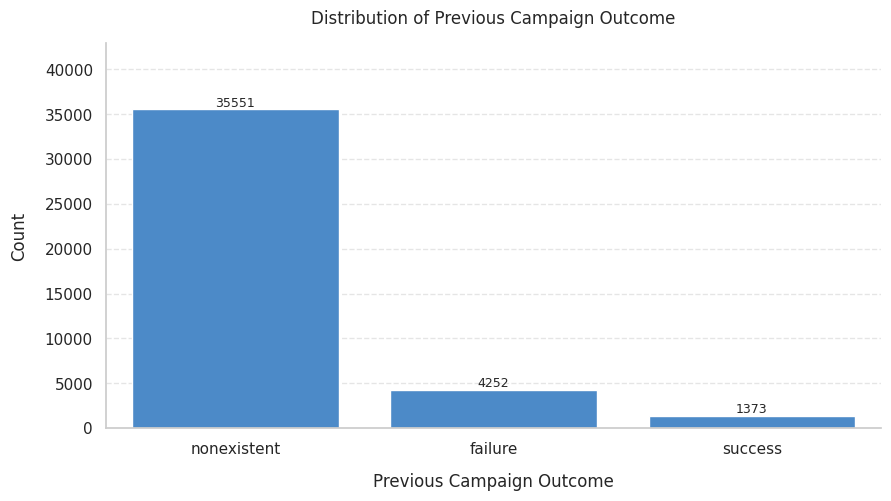

In [14]:
# Friendly display names — reused in Cell 14 as well
cat_feature_names = {
    'job'         : 'Job Type',
    'marital'     : 'Marital Status',
    'education'   : 'Education Level',
    'default'     : 'Credit Default Status',
    'housing'     : 'Housing Loan',
    'loan'        : 'Personal Loan',
    'contact'     : 'Contact Communication Type',
    'month'       : 'Last Contact Month',
    'day_of_week' : 'Last Contact Day of Week',
    'poutcome'    : 'Previous Campaign Outcome'}

for col in cat_features:
    fig, ax = plt.subplots(figsize=(10, 5))

    order = marketing[col].value_counts().index

    sns.countplot(data=marketing, x=col, order=order, color=COLOUR_NO, ax=ax)

    if marketing[col].nunique() > 4:
        plt.xticks(rotation=35, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)

    plt.title(f'Distribution of {cat_feature_names.get(col, col)}', pad=14)
    plt.xlabel(cat_feature_names.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    plt.ylim(0, ax.get_ylim()[1] * 1.15)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.savefig(
        f'Distribution of {cat_feature_names.get(col, col)}.png',
        dpi=300)
    plt.show()

    print('\n')

## Cell 14 — Subscription Rate by Key Categorical Features

For each key categorical feature, this chart shows what percentage of clients in each category subscribed. More informative than raw counts because it shows which categories are most associated with a positive outcome.

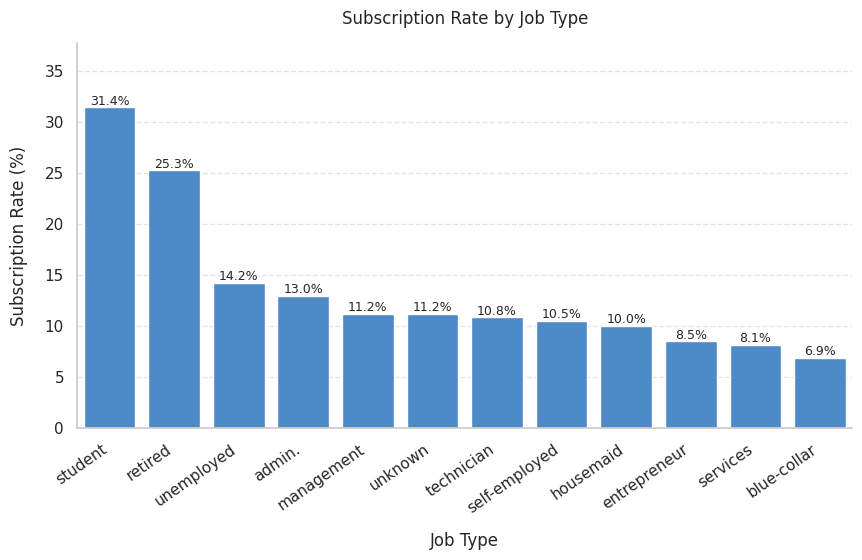

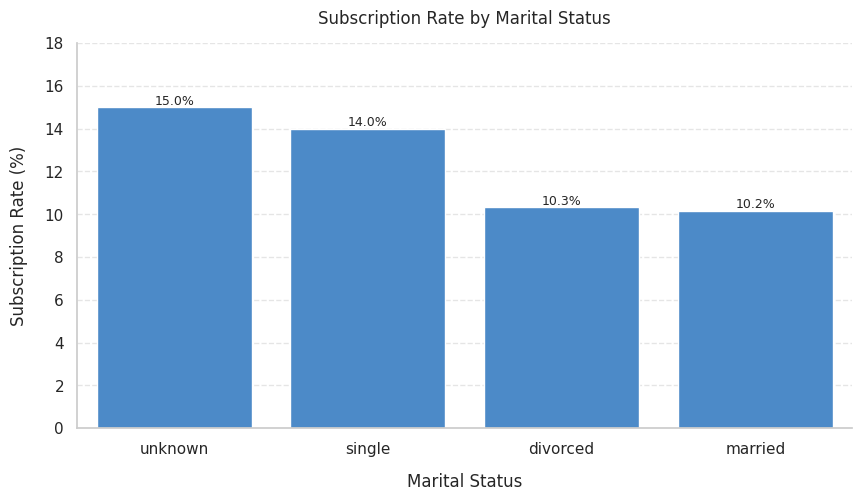

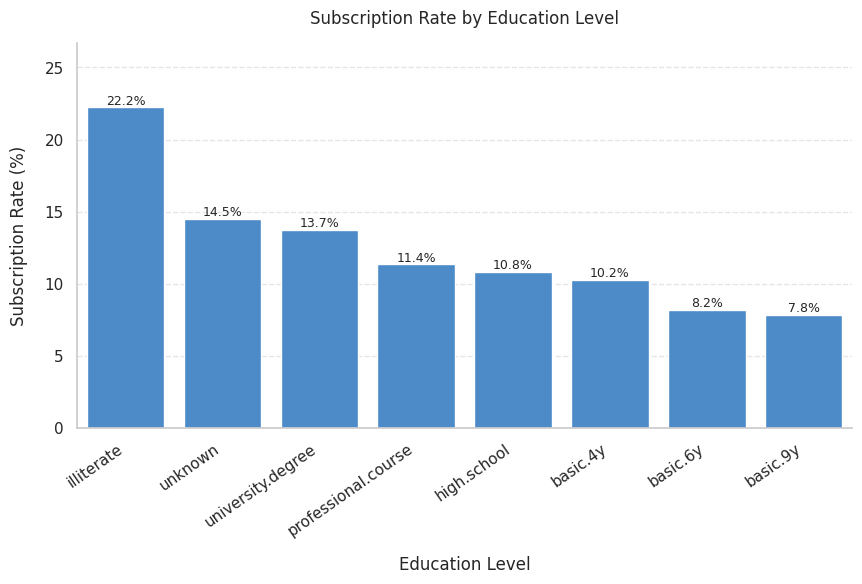

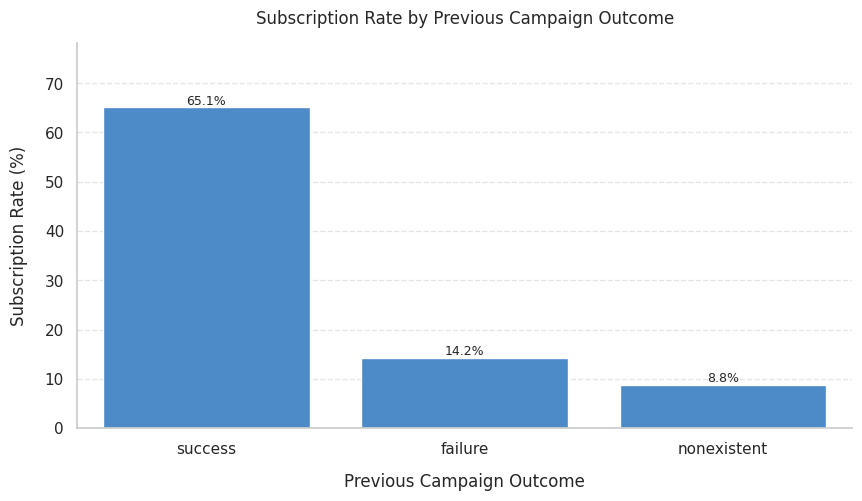

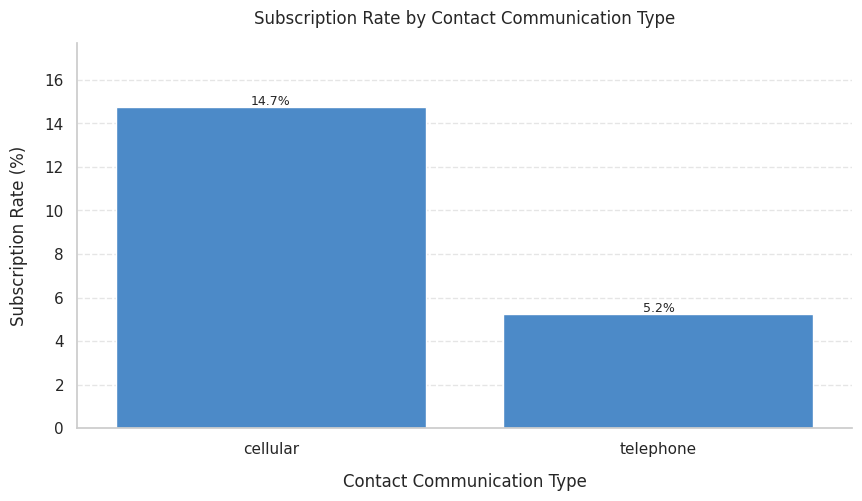

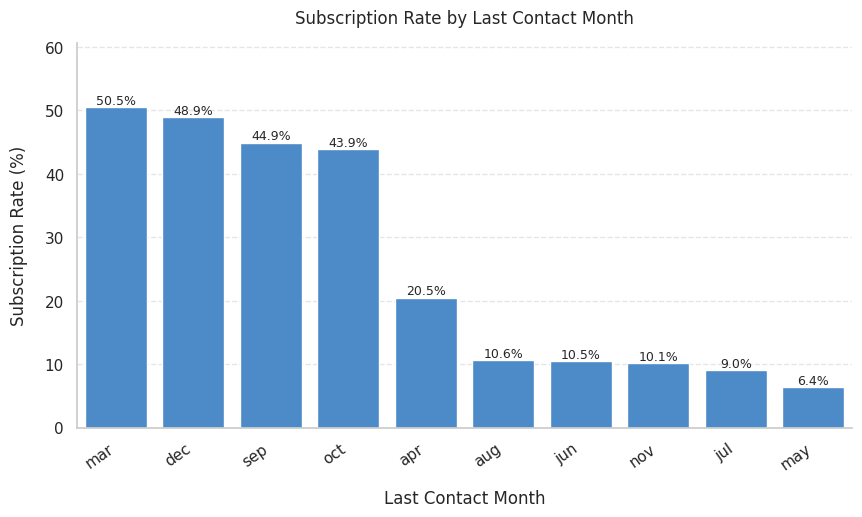

In [15]:
# Only key features included — day_of_week shows very little
# variation and adds no useful insight to the report
key_cats = ['job', 'marital', 'education', 'poutcome', 'contact', 'month']

for col in key_cats:
    fig, ax = plt.subplots(figsize=(10, 5))

    rate = (marketing.groupby(col)[TARGET]
        .apply(lambda x: (x == 'yes').mean() * 100)
        .sort_values(ascending=False)
        .reset_index())
    rate.columns = [col, 'Subscription Rate (%)']
    sns.barplot(data=rate, x=col, y='Subscription Rate (%)', color=COLOUR_NO, ax=ax)

    if marketing[col].nunique() > 4:
        plt.xticks(rotation=35, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

    plt.title(
        f'Subscription Rate by {cat_feature_names.get(col, col)}',
        pad=14)
    plt.xlabel(cat_feature_names.get(col, col), labelpad=12)
    plt.ylabel('Subscription Rate (%)', labelpad=12)
    plt.ylim(0, rate['Subscription Rate (%)'].max() * 1.2)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.savefig(
        f'Subscription Rate by {cat_feature_names.get(col, col)}.png', dpi=300)
    plt.show()

    print('\n')

## Cell 15 — Age Distribution by Subscription Outcome

A KDE plot with both classes overlaid shows whether the age distribution differs between subscribers and non-subscribers.

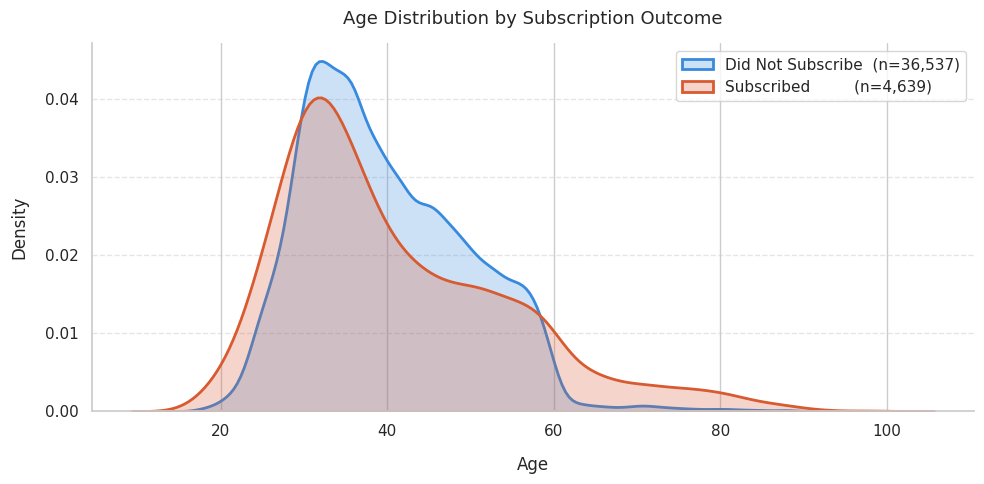

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

for outcome, colour, label in [
    ('no',  COLOUR_NO,  f'Did Not Subscribe  (n={counts["no"]:,})'),
    ('yes', COLOUR_YES, f'Subscribed         (n={counts["yes"]:,})')
]:
    subset = marketing[marketing[TARGET] == outcome]['age']
    sns.kdeplot(
        subset, ax=ax,
        color=colour,
        label=label,
        linewidth=2,
        fill=True,
        alpha=0.25
    )

plt.title('Age Distribution by Subscription Outcome', pad=14, fontsize=13)
plt.xlabel('Age', labelpad=12)
plt.ylabel('Density', labelpad=12)
plt.legend(fontsize=11)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_age_by_subscription.png', dpi=300)
plt.show()

print('\n')

## Cell 16 — Correlation Heatmap — Numerical Features (Figure 3.6)

Shows the correlation coefficient between every pair of numerical features. The upper triangle is masked to avoid repeating values. Strong correlations among the economic indicators are expected and discussed in Section 3.2.4.

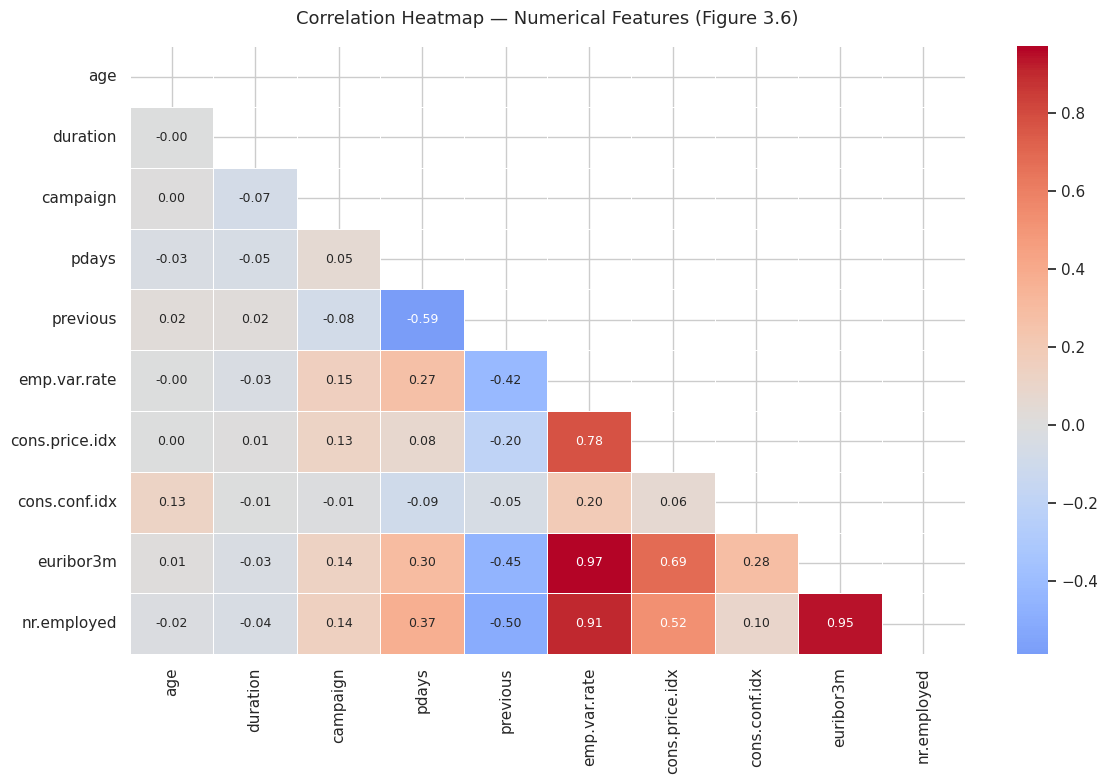

Strong correlations found (|r| > 0.70):
  cons.price.idx  <-->  emp.var.rate  :  r = 0.775
  euribor3m  <-->  emp.var.rate  :  r = 0.972
  nr.employed  <-->  emp.var.rate  :  r = 0.907
  nr.employed  <-->  euribor3m  :  r = 0.945

The strong correlations among the economic indicators are expected
because they all reflect the state of the economy at the same point
in time. This multicollinearity is discussed in Section 3.2.4.


In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = marketing[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

plt.title('Correlation Heatmap — Numerical Features (Figure 3.6)', pad=16, fontsize=13)
plt.tight_layout()
plt.savefig('fig_3_6_correlation_heatmap.png', dpi=300)
plt.show()

print('Strong correlations found (|r| > 0.70):')
strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.70:
            strong_pairs.append(
                (corr_matrix.columns[i],
                 corr_matrix.columns[j],
                 round(r, 3))
            )

if strong_pairs:
    for pair in strong_pairs:
        print(f'  {pair[0]}  <-->  {pair[1]}  :  r = {pair[2]}')
else:
    print('  No strongly correlated pairs found.')

print()
print('The strong correlations among the economic indicators are expected')
print('because they all reflect the state of the economy at the same point')
print('in time. This multicollinearity is discussed in Section 3.2.4.')

## Cell 17 — Outlier Detection (IQR Method — Table 3.3)

The IQR method is used rather than z-score because several features are heavily skewed, which violates the normality assumption z-score relies on. Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are flagged as outliers.

In [18]:
print('Outlier Detection Summary — IQR Method  (Table 3.3)')
print('=' * 62)

outlier_results = {}

for col in num_features:
    Q1    = marketing[col].quantile(0.25)
    Q3    = marketing[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((marketing[col] < lower) | (marketing[col] > upper)).sum()
    pct   = round(count / len(marketing) * 100, 2)

    outlier_results[col] = {
        'Lower Bound'   : round(lower, 2),
        'Upper Bound'   : round(upper, 2),
        'Outlier Count' : count,
        'Outlier (%)'   : pct}

outlier_df = pd.DataFrame(outlier_results).T
outlier_df = outlier_df[outlier_df['Outlier Count'] > 0]

print(outlier_df.to_string())
print(f'\nTotal outlier entries: {outlier_df["Outlier Count"].sum():,.0f}')
print('\nThese records will be removed at')
print('before the preprocessing pipeline is constructed.')

Outlier Detection Summary — IQR Method  (Table 3.3)
               Lower Bound  Upper Bound  Outlier Count  Outlier (%)
age                   9.50        69.50         468.00         1.14
duration           -223.50       644.50        2963.00         7.20
campaign             -2.00         6.00        2406.00         5.84
pdays               999.00       999.00        1515.00         3.68
previous              0.00         0.00        5625.00        13.66
cons.conf.idx       -52.15       -26.95         446.00         1.08

Total outlier entries: 13,423

These records will be removed at
before the preprocessing pipeline is constructed.


## Cell 18 — Final Dataset State Summary (Table 3.1)

A complete record of the dataset at the end of Part 1. Every number here feeds into Table 3.1 of the report. The after-preprocessing version is produced at the end of Part 2.

In [19]:
no_count  = (marketing[TARGET] == 'no').sum()
yes_count = (marketing[TARGET] == 'yes').sum()

print('=' * 62)
print('  DATASET STATE SUMMARY — END OF PART 1  (Before Preprocessing)')
print('=' * 62)
print(f'  Total records (after duplicate removal) : {len(marketing):,}')
print(f'  Total features (excluding target)       : {len(marketing.columns) - 1}')
print(f'  Numerical features                      : {len(num_features)}')
print(f'  Categorical features                    : {len(cat_features)}')
print(f'  Target column                           : {TARGET}  (yes / no)')
print(f'  NaN missing values                      : {marketing.isnull().sum().sum()}')
print(f'  Unknown values present in               : 6 categorical columns')
print(f'  Duplicates removed                      : 12')
print(f'  pdays = 999 (date unknown)              : 39,661 rows')
print(f'  Class split — no                        : {no_count:,}  ({no_count/len(marketing)*100:.1f}%)')
print(f'  Class split — yes                       : {yes_count:,}  ({yes_count/len(marketing)*100:.1f}%)')
print('=' * 62)
print()
print('Part 1 complete.')
print('All EDA figures saved to the working directory.')
print('Proceed to Part 2 — Preprocessing and Feature Engineering.')

  DATASET STATE SUMMARY — END OF PART 1  (Before Preprocessing)
  Total records (after duplicate removal) : 41,176
  Total features (excluding target)       : 20
  Numerical features                      : 10
  Categorical features                    : 10
  Target column                           : subscribed  (yes / no)
  NaN missing values                      : 0
  Unknown values present in               : 6 categorical columns
  Duplicates removed                      : 12
  pdays = 999 (date unknown)              : 39,661 rows
  Class split — no                        : 36,537  (88.7%)
  Class split — yes                       : 4,639  (11.3%)

Part 1 complete.
All EDA figures saved to the working directory.
Proceed to Part 2 — Preprocessing and Feature Engineering.


## Download All Charts

Run this cell to download every saved chart from Colab at once.

---
# Part 2: Data Preprocessing and Feature Engineering

This section covers **Section 3.3** of the final report:
- Removing outliers detected in Part 1
- Transforming the pdays column into two meaningful features
- Engineering new features from existing ones
- Classifying features for the ColumnTransformer
- Splitting the data into training and test sets
- Building the full imblearn Pipeline with SMOTE
- Confirming the final dataset state before modelling

In [20]:
# Install imbalanced-learn for SMOTE and the imblearn pipeline 19
!pip install imbalanced-learn --quiet

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve,
    matthews_corrcoef, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print('All preprocessing and modelling libraries imported successfully.')

All preprocessing and modelling libraries imported successfully.


## Cell 20 — Remove Outliers (IQR Method)

Using the IQR boundaries identified in Cell 17 of Part 1. Only features with meaningful outliers are included — `pdays` and `previous` are excluded here because `pdays` is being transformed separately in Cell 21, and the IQR for `previous` (Q1=Q3=0) would incorrectly flag all non-zero values.

In [21]:
# Record the row count before removal for the report 20
rows_before = len(marketing)

# Only apply IQR outlier removal to features where it makes genuine sense.
# pdays is handled in Cell 21.
# previous has Q1=Q3=0 so IQR=0, which would wrongly remove all
# clients with any prior contact — those are important records.
outlier_cols = ['age', 'duration', 'campaign', 'cons.conf.idx']

def remove_outliers_iqr(df, cols):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        Q1    = df[col].quantile(0.25)
        Q3    = df[col].quantile(0.75)
        IQR   = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask  = mask & (df[col] >= lower) & (df[col] <= upper)
    return df[mask].copy()

marketing = remove_outliers_iqr(marketing, outlier_cols)
marketing.reset_index(drop=True, inplace=True)

rows_after   = len(marketing)
rows_removed = rows_before - rows_after

print(f'Rows before outlier removal : {rows_before:,}')
print(f'Rows removed                : {rows_removed:,}')
print(f'Rows after outlier removal  : {rows_after:,}')
print(f'\nDataFrame shape: {marketing.shape}')

Rows before outlier removal : 41,176
Rows removed                : 6,011
Rows after outlier removal  : 35,165

DataFrame shape: (35165, 21)


## Cell 21 — Transform the pdays Column

As identified in Cell 8 of Part 1, `pdays = 999` means the last contact date was not recorded — not that the client was never contacted. Two new features replace the original column to capture both pieces of information without feeding 999 as a real number into the models.

In [22]:
# ── CELL 21: Transform the pdays Column ──────────────────────────────────────
# As identified in Cell 8, pdays = 999 means the last contact date was
# not recorded, not that the client was never contacted.
# Two new features replace the original column.

# prev_contact_known_flag — binary: was the last contact date recorded?
# 1 means the bank has a real recorded date, 0 means it was not recorded
marketing['prev_contact_known_flag'] = (marketing['pdays'] != 999).astype(int)

# prev_contact_unknown_days — actual days where known, -1 where unknown
# We use -1 directly rather than NaN because days cannot be negative,
# so -1 is an unambiguous sentinel meaning unknown.
# This avoids NaN values flowing into SMOTE which cannot handle them.
marketing['prev_contact_unknown_days'] = marketing['pdays'].replace(999, -1)

# Drop the original pdays column
marketing = marketing.drop('pdays', axis=1)

print('pdays column successfully transformed.')
print()
print(f"prev_contact_known_flag    — 1s (date recorded) : {marketing['prev_contact_known_flag'].sum():,}")
print(f"prev_contact_known_flag    — 0s (date unknown)  : {(marketing['prev_contact_known_flag']==0).sum():,}")
print()
print(f"prev_contact_unknown_days  — real values : {(marketing['prev_contact_unknown_days'] != -1).sum():,}")
print(f"prev_contact_unknown_days  — unknown (-1): {(marketing['prev_contact_unknown_days'] == -1).sum():,}")
print()
print('No NaN values created — safe for SMOTE in the pipeline.')
print(f'DataFrame shape: {marketing.shape}')

pdays column successfully transformed.

prev_contact_known_flag    — 1s (date recorded) : 1,206
prev_contact_known_flag    — 0s (date unknown)  : 33,959

prev_contact_unknown_days  — real values : 1,206
prev_contact_unknown_days  — unknown (-1): 33,959

No NaN values created — safe for SMOTE in the pipeline.
DataFrame shape: (35165, 22)


## Cell 22 — Feature Engineering

Creating two new features that capture meaningful patterns not directly expressed by any individual column. Each one is justified by domain knowledge about how marketing campaigns work.

In [23]:
# Feature 1 — contact_intensity 22
# Total number of times a client has been contacted across both
# the current campaign and any previous campaigns.
# A client contacted many times across campaigns is either very
# resistant or very engaged — the model can learn which.
marketing['contact_intensity'] = marketing['campaign'] + marketing['previous']

# Feature 2 — long_call
# Binary flag indicating whether the last call lasted more than
# 5 minutes (300 seconds). Longer calls tend to indicate genuine
# client interest and are associated with higher subscription rates.
marketing['long_call'] = (marketing['duration'] > 300).astype(int)

print('New engineered features created:')
print(f"  contact_intensity — min: {marketing['contact_intensity'].min()}  "
      f"max: {marketing['contact_intensity'].max()}  "
      f"mean: {marketing['contact_intensity'].mean():.2f}")
print(f"  long_call         — 0s: {(marketing['long_call']==0).sum():,}  "
      f"1s: {(marketing['long_call']==1).sum():,}")
print(f'\nDataFrame shape: {marketing.shape}')

New engineered features created:
  contact_intensity — min: 1  max: 10  mean: 2.22
  long_call         — 0s: 27,440  1s: 7,725

DataFrame shape: (35165, 24)


## Cell 23 — Classify Features for the ColumnTransformer

The ColumnTransformer applies different transformations to different column types. Before building it, every feature must be assigned to the correct group. Education and month are treated as ordinal because their categories have a natural order. All other categorical columns are treated as nominal.

In [24]:
# Separate features from the target variable 23
X = marketing.drop(TARGET, axis=1)
y = marketing[TARGET]

# Convert target to binary — 1 for subscribed, 0 for not subscribed
y = (y == 'yes').astype(int)

# Numerical features — scaled with RobustScaler
# RobustScaler uses median and IQR so it is less sensitive to
# any remaining outliers than StandardScaler
num_cols = [
    'age', 'duration', 'campaign', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed',
    'prev_contact_known_flag', 'prev_contact_unknown_days',
    'contact_intensity', 'long_call'
]

# Ordinal categorical — categories have a meaningful order
# Education: from least to most qualified
# Month: calendar order
ord_cols = ['education', 'month']

education_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree', 'unknown'
]

month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

# Nominal categorical — no natural order, one-hot encoded
nom_cols = [
    'job', 'marital', 'default', 'housing',
    'loan', 'contact', 'day_of_week', 'poutcome'
]

print('Feature classification for ColumnTransformer')
print('=' * 55)
print(f'Numerical   ({len(num_cols)}) : {num_cols}')
print(f'Ordinal     ({len(ord_cols)}) : {ord_cols}')
print(f'Nominal     ({len(nom_cols)}) : {nom_cols}')
print(f'\nTarget: {TARGET} (encoded as 1=yes, 0=no)')
print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nClass distribution after encoding:')
print(y.value_counts())

Feature classification for ColumnTransformer
Numerical   (13) : ['age', 'duration', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'prev_contact_known_flag', 'prev_contact_unknown_days', 'contact_intensity', 'long_call']
Ordinal     (2) : ['education', 'month']
Nominal     (8) : ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'poutcome']

Target: subscribed (encoded as 1=yes, 0=no)

X shape: (35165, 23)
y shape: (35165,)

Class distribution after encoding:
subscribed
0    32435
1     2730
Name: count, dtype: int64


## Cell 24 — Split Data into Training and Test Sets

Stratified splitting preserves the 88.7% / 11.3% class ratio in both sets. The test set is held completely aside and never seen by the model during training or hyperparameter tuning. `random_state=42` ensures reproducibility.

## Cell 24 — Split Data into Training and Test Sets

Stratified splitting preserves the 88.7% / 11.3% class ratio in both sets. The test set is held completely aside and never seen by the model during training or hyperparameter tuning. `random_state=42` ensures reproducibility.

In [25]:
# ── CELL 24: Split Data into Training and Test Sets ───────────────────────────

# X and y defined here so this cell runs independently
# even if Cell 23 was not run in the current session
X = marketing.drop(TARGET, axis=1)
y = marketing[TARGET]

# Convert target to binary — 1 for subscribed, 0 for not subscribed
y = (y == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserves class ratio in both sets
)

print('Data split complete.')
print(f'Training set   : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set       : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Class distribution in training set:')
print(y_train.value_counts())
print()
print('Class distribution in test set:')
print(y_test.value_counts())

Data split complete.
Training set   : 28,132 rows  (80.0%)
Test set       : 7,033 rows  (20.0%)

Class distribution in training set:
subscribed
0    25948
1     2184
Name: count, dtype: int64

Class distribution in test set:
subscribed
0    6487
1     546
Name: count, dtype: int64


## Cell 25 — Build the ColumnTransformer

The ColumnTransformer applies the correct transformation to each feature group simultaneously. Using a transformer ensures the same fitted parameters from training are applied consistently to the test set.

In [26]:
# ── CELL 25: Build the ColumnTransformer ─────────────────────────────────────
# Now that prev_contact_unknown_days uses -1 instead of NaN,
# RobustScaler handles all numerical columns without any imputer needed.

from sklearn.pipeline import Pipeline as SklearnPipeline

preprocessor = ColumnTransformer(
    transformers=[

        # Numerical — RobustScaler scales using median and IQR
        ('num',
         RobustScaler(),
         num_cols),

        # Ordinal — preserves natural order of education and month
        ('ord_encoder',
         OrdinalEncoder(
             categories=[education_order, month_order],
             handle_unknown='use_encoded_value',
             unknown_value=-1
         ),
         ord_cols),

        # Nominal — one-hot encodes all remaining categorical features
        ('onehot',
         OneHotEncoder(
             handle_unknown='ignore',
             sparse_output=False
         ),
         nom_cols)
    ],
    remainder='passthrough'
)

print('ColumnTransformer built successfully.')
print('Transformations:')
print(f'  RobustScaler   → {len(num_cols)} numerical features')
print(f'  OrdinalEncoder → {len(ord_cols)} ordinal features')
print(f'  OneHotEncoder  → {len(nom_cols)} nominal features')
print()
print('No NaN values in the dataset — SMOTE will run without errors.')

ColumnTransformer built successfully.
Transformations:
  RobustScaler   → 13 numerical features
  OrdinalEncoder → 2 ordinal features
  OneHotEncoder  → 8 nominal features

No NaN values in the dataset — SMOTE will run without errors.


In [27]:
marketing.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed,prev_contact_known_flag,prev_contact_unknown_days,contact_intensity,long_call
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,0,-1,1,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,0,-1,1,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,0,-1,1,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,0,-1,1,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,0,-1,1,1


## Cell 26 — Build the imblearn Pipeline

The pipeline chains the ColumnTransformer and SMOTE together in the correct order. Critically, SMOTE sits inside the pipeline rather than being applied before splitting. This ensures synthetic samples are only generated from the training data and the test set remains entirely unseen and unmodified — preventing data leakage.

In [28]:
#26
preprocessor = ColumnTransformer(
    transformers=[
        # RobustScaler scales using median and IQR — robust to outliers
        ('scaler', RobustScaler(), num_cols),

        # OrdinalEncoder preserves the natural order of categories
        ('ord_encoder',
         OrdinalEncoder(
             categories=[education_order, month_order],
             handle_unknown='use_encoded_value',
             unknown_value=-1
         ),
         ord_cols),

        # OneHotEncoder creates a binary column for each category
        # handle_unknown='ignore' safely handles any unseen categories
        ('onehot',
         OneHotEncoder(
             handle_unknown='ignore',
             sparse_output=False
         ),
         nom_cols)
    ],
    remainder='passthrough'  # keep any remaining columns as they are
)

print('ColumnTransformer built successfully.')
print('Transformations:')
print(f'  RobustScaler   → {len(num_cols)} numerical features')
print(f'  OrdinalEncoder → {len(ord_cols)} ordinal features (education, month)')
print(f'  OneHotEncoder  → {len(nom_cols)} nominal features')

ColumnTransformer built successfully.
Transformations:
  RobustScaler   → 13 numerical features
  OrdinalEncoder → 2 ordinal features (education, month)
  OneHotEncoder  → 8 nominal features


In [29]:
# The pipeline applies steps sequentially: 26
# 1. preprocessor — encodes and scales all features
# 2. smote        — generates synthetic minority samples on training data only
# 3. model        — placeholder replaced with each classifier during training

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression())   # placeholder — replaced in Cell 27
])

print('imblearn Pipeline built successfully.')
print()
print('Pipeline steps:')
for step_name, step_obj in pipeline.steps:
    print(f'  {step_name:15} : {type(step_obj).__name__}')

imblearn Pipeline built successfully.

Pipeline steps:
  preprocessor    : ColumnTransformer
  smote           : SMOTE
  model           : LogisticRegression


## Cell 27 — Define the Six Models

All six classifiers are defined in a single dictionary. The loop in Cell 28 iterates through them, swaps each one into the pipeline, trains it, and records the results. `random_state=42` is set on every model for full reproducibility.

In [30]:
#27
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42
    ),
    'SVM': SVC(
        probability=True, random_state=42
    ),
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='logloss',
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        random_state=42, verbosity=-1
    )
}

print(f'{len(models)} models defined and ready for training:')
for name in models:
    print(f'  {name}')

6 models defined and ready for training:
  Logistic Regression
  Decision Tree
  Random Forest
  SVM
  XGBoost
  LightGBM


## Cell 28 — Train All Six Models (Baseline)

Each model is trained using its default hyperparameters. This produces the **baseline results** — the before-tuning row in the comparative results table. All predictions are made on the held-out test set.

In [31]:
#28
import time

# Storage for results
baseline_results = []
roc_results      = {}

print('Training all six models with default hyperparameters...')
print('=' * 65)

for name, model in models.items():

    # Swap the model into the pipeline
    pipeline.set_params(model=model)

    # Record training time
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = round(time.time() - start, 2)

    # Make predictions on the unseen test set
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Calculate all metrics
    acc  = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec  = round(recall_score(y_test, y_pred), 4)
    f1   = round(f1_score(y_test, y_pred), 4)
    auc  = round(roc_auc_score(y_test, y_proba), 4)
    mcc  = round(matthews_corrcoef(y_test, y_pred), 4)

    baseline_results.append({
        'Model'     : name,
        'Accuracy'  : acc,
        'Precision' : prec,
        'Recall'    : rec,
        'F1-Score'  : f1,
        'ROC-AUC'   : auc,
        'MCC'       : mcc,
        'Train Time (s)': train_time
    })

    # Store ROC data for plotting
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_results[name] = {
        'fpr': fpr, 'tpr': tpr, 'auc': auc
    }

    print(f'{name:<22} | F1: {f1}  AUC: {auc}  MCC: {mcc}  '
          f'Time: {train_time}s')

# Store as DataFrame
baseline_df = pd.DataFrame(baseline_results).set_index('Model')

print()
print('Baseline training complete.')
print()
print('Baseline Results Table (Table 4.1):')
print('=' * 65)
print(baseline_df.to_string())

Training all six models with default hyperparameters...
Logistic Regression    | F1: 0.4976  AUC: 0.9371  MCC: 0.4952  Time: 3.79s
Decision Tree          | F1: 0.4685  AUC: 0.722  MCC: 0.4218  Time: 2.4s
Random Forest          | F1: 0.5678  AUC: 0.9475  MCC: 0.5348  Time: 20.12s
SVM                    | F1: 0.5151  AUC: 0.9421  MCC: 0.5196  Time: 319.65s
XGBoost                | F1: 0.568  AUC: 0.9506  MCC: 0.5372  Time: 2.24s
LightGBM               | F1: 0.5695  AUC: 0.954  MCC: 0.5354  Time: 1.5s

Baseline training complete.

Baseline Results Table (Table 4.1):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  MCC  Train Time (s)
Model                                                                                   
Logistic Regression      0.86       0.35    0.86      0.50     0.94 0.50            3.79
Decision Tree            0.91       0.44    0.50      0.47     0.72 0.42            2.40
Random Forest            0.94       0.60    0.54      0.57     0.95 0.53  

## Cell 29 — Baseline F1-Score Comparison Chart (Figure 4.2)

A bar chart comparing F1-Score across all six models before tuning. This goes directly into the report as Figure 4.2.

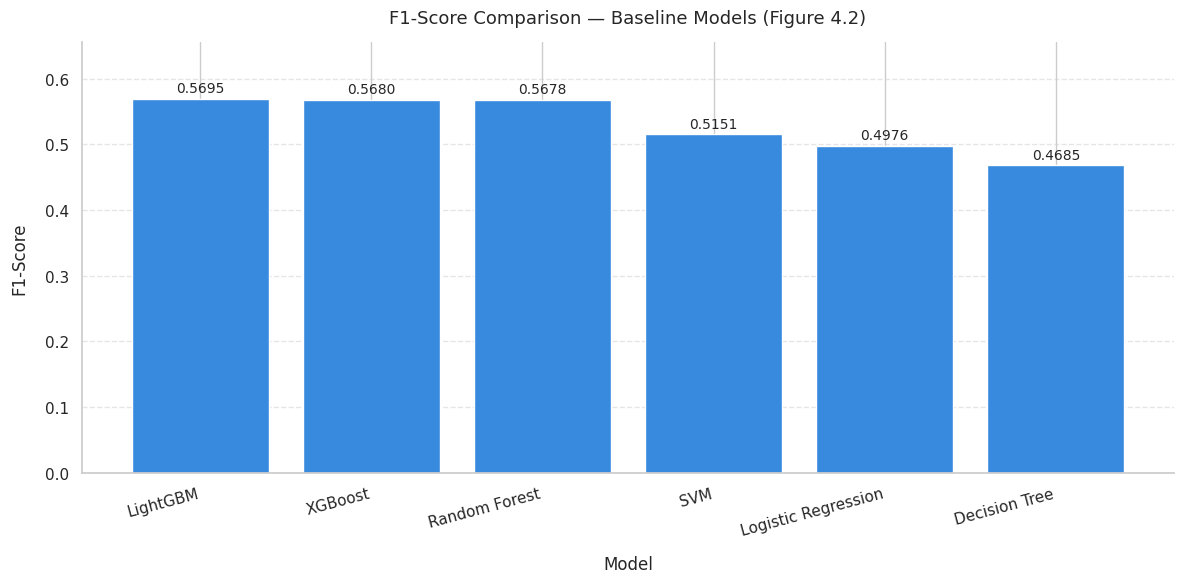

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

f1_scores = baseline_df['F1-Score'].sort_values(ascending=False)

bars = ax.bar(
    f1_scores.index,
    f1_scores.values,
    color=COLOUR_NO,
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=10
    )

plt.title('F1-Score Comparison — Baseline Models (Figure 4.2)', pad=14, fontsize=13)
plt.xlabel('Model', labelpad=12)
plt.ylabel('F1-Score', labelpad=12)
plt.ylim(0, f1_scores.max() * 1.15)
plt.xticks(rotation=15, ha='right')
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_4_2_baseline_f1_comparison.png', dpi=300)
plt.show()

print('\n')

## Cell 30 — Baseline ROC-AUC Curves (Figure 4.1)

ROC curves for all six models plotted on the same axes for easy comparison. The diagonal dashed line represents random guessing (AUC = 0.50). This becomes Figure 4.1 in the report.

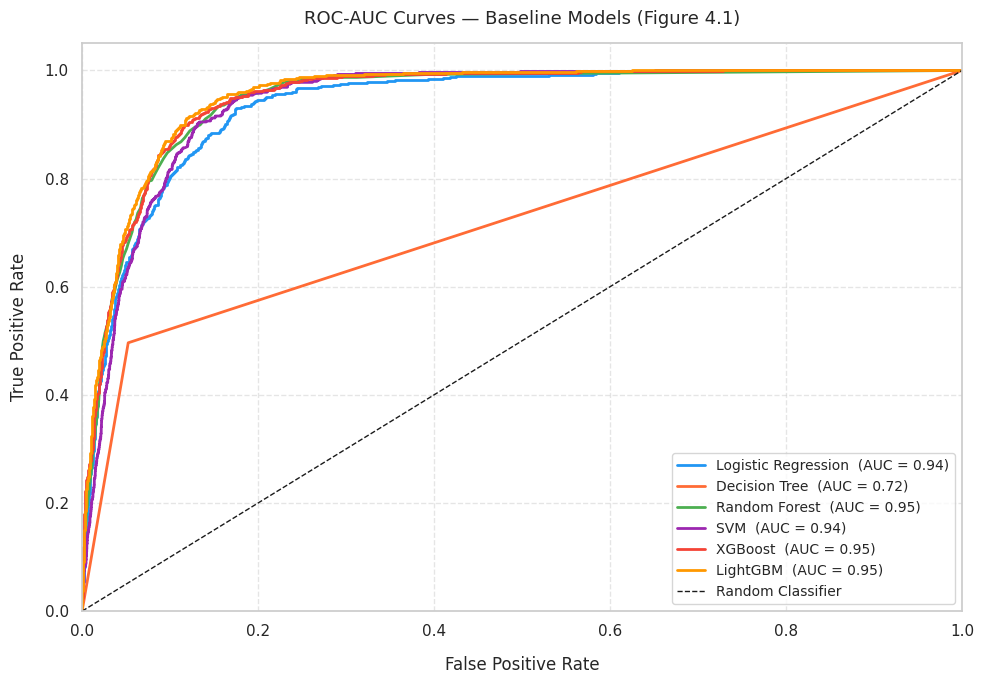

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))

colours_roc = [
    '#2196F3', '#FF6B35', '#4CAF50',
    '#9C27B0', '#F44336', '#FF9800'
]

for (name, data), colour in zip(roc_results.items(), colours_roc):
    ax.plot(
        data['fpr'], data['tpr'],
        label=f"{name}  (AUC = {data['auc']:.2f})",
        color=colour, linewidth=2
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.title(
    'ROC-AUC Curves — Baseline Models (Figure 4.1)',
    pad=14, fontsize=13
)
plt.xlabel('False Positive Rate', labelpad=12)
plt.ylabel('True Positive Rate', labelpad=12)
plt.legend(loc='lower right', fontsize=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_4_1_baseline_roc_curves.png', dpi=300)
plt.show()

print('\n')

## Cell 31 — Baseline Confusion Matrices

A confusion matrix for each model showing exactly how many True Positives, True Negatives, False Positives, and False Negatives each model produced. These go into Section 4.2 of the report.

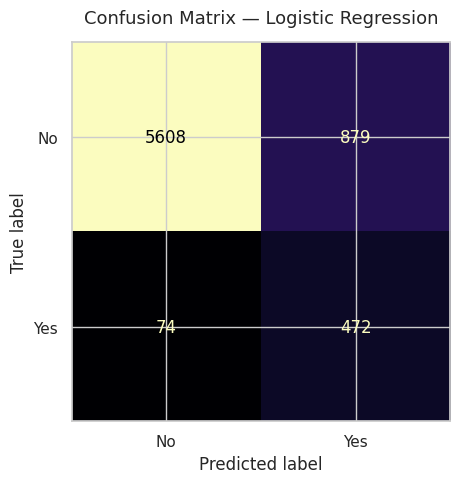

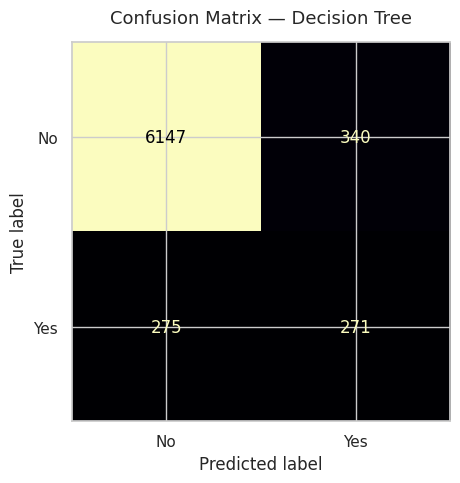

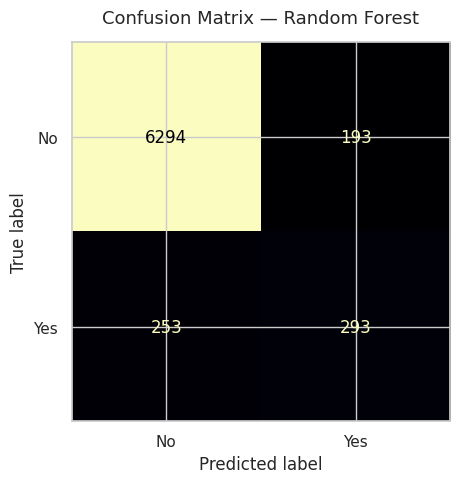

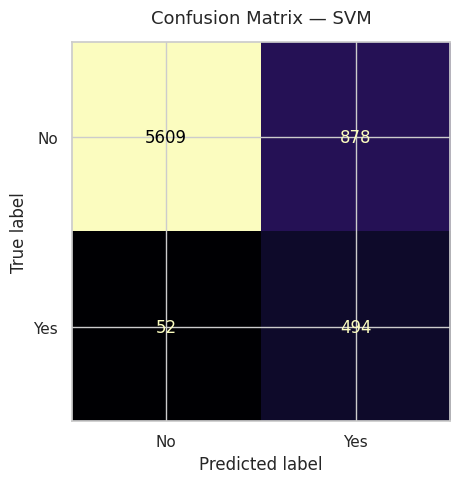

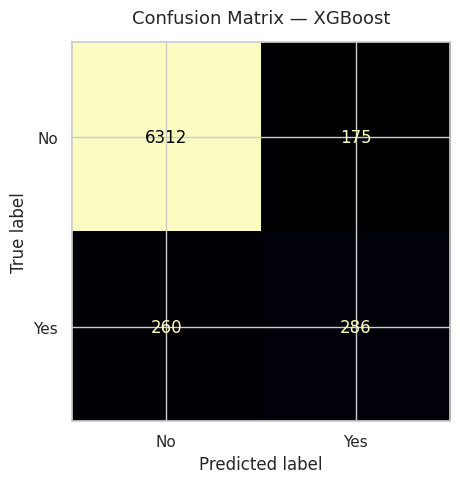

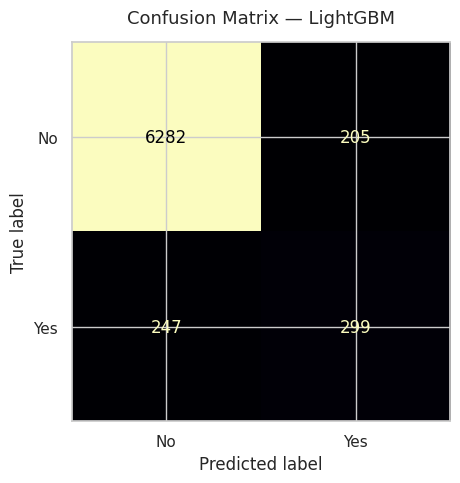

In [34]:
# ── CELL 31: Baseline Confusion Matrices — Individual Charts ─────────────────
# A separate confusion matrix for each model.
# Each chart is saved as its own PNG file for the report.

for name, model in models.items():
    pipeline.set_params(model=model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='magma')

    plt.title(f'Confusion Matrix — {name}', pad=14, fontsize=13)
    plt.tight_layout()

    filename = f"Confusion Matrix {name}.png"
    plt.savefig(filename, dpi=300)
    plt.show()

    print('\n')

## Cell 32 — Hyperparameter Tuning with RandomizedSearchCV

RandomizedSearchCV randomly samples 50 combinations from each model's parameter space and evaluates each using 5-fold stratified cross-validation. F1-Score is used as the optimisation metric rather than accuracy because of the class imbalance. `random_state=42` ensures reproducibility.

In [35]:
# ── Hyperparameter Tuning with Reduced Grids ─────────────────────────────────

# Reduced parameter grids — most impactful parameters only
param_grids = {
    'Logistic Regression': {
        'model__C'       : [0.1, 1, 10],
        'model__penalty' : ['l2'],
        'model__solver'  : ['saga']
    },
    'Decision Tree': {
        'model__max_depth'        : [5, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__criterion'        : ['gini', 'entropy']
    },
    'Random Forest': {
        'model__n_estimators' : [100, 300],
        'model__max_depth'    : [10, 20, None],
        'model__max_features' : ['sqrt', 'log2']
    },
    'SVM': {
        'model__C'      : [1, 10],
        'model__kernel' : ['rbf'],
        'model__gamma'  : ['scale']
    },
    'XGBoost': {
        'model__n_estimators'  : [100, 300],
        'model__max_depth'     : [3, 5],
        'model__learning_rate' : [0.05, 0.1]
    },
    'LightGBM': {
        'model__n_estimators'  : [200, 500],
        'model__max_depth'     : [5, 8],
        'model__learning_rate' : [0.05, 0.1],
        'model__num_leaves'    : [31, 63]
    }
}

# Storage for results
tuned_results   = []   # list of dicts, each row = one model's metrics
tuned_roc       = {}   # dictionary: model name -> {'fpr':..., 'tpr':..., 'auc':...}
best_params     = {}   # dictionary: model name -> best hyperparameters
best_estimators = {}   # dictionary: model name -> best fitted pipeline

print('Hyperparameter tuning with reduced settings...')
print('=' * 65)

for name, model in models.items():
    # Replace the model in the pipeline
    pipeline.set_params(model=model)

    # Set up RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator           = pipeline,
        param_distributions = param_grids[name],
        n_iter              = 10,      # reduced from 50
        scoring             = 'f1',
        cv                  = 3,       # reduced from 5
        random_state        = 42,
        n_jobs              = -1,
        verbose             = 0
    )

    # Fit the search
    start = time.time()
    search.fit(X_train, y_train)
    train_time = round(time.time() - start, 2)

    # Predict on test set using the best estimator
    y_pred  = search.best_estimator_.predict(X_test)
    y_proba = search.best_estimator_.predict_proba(X_test)[:, 1]

    # Compute metrics
    acc  = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec  = round(recall_score(y_test, y_pred), 4)
    f1   = round(f1_score(y_test, y_pred), 4)
    auc  = round(roc_auc_score(y_test, y_proba), 4)
    mcc  = round(matthews_corrcoef(y_test, y_pred), 4)

    # Store results
    tuned_results.append({
        'Model'     : name,
        'Accuracy'  : acc,
        'Precision' : prec,
        'Recall'    : rec,
        'F1-Score'  : f1,
        'ROC-AUC'   : auc,
        'MCC'       : mcc,
        'Train Time (s)': train_time
    })

    # Store ROC data for later plotting
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    tuned_roc[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    # Store best parameters and the fitted estimator
    best_params[name]     = search.best_params_
    best_estimators[name] = search.best_estimator_

    # Print progress
    print(f'{name:<22} | F1: {f1}  AUC: {auc}  MCC: {mcc}  Time: {train_time}s')

# Convert results to DataFrame for easy viewing
tuned_df = pd.DataFrame(tuned_results).set_index('Model')

print()
print('Tuning complete.')
print()
print('Tuned Results Table:')
print('=' * 65)
print(tuned_df.to_string())

Hyperparameter tuning with reduced settings...
Logistic Regression    | F1: 0.4968  AUC: 0.9371  MCC: 0.4941  Time: 94.14s
Decision Tree          | F1: 0.5365  AUC: 0.9007  MCC: 0.5152  Time: 15.81s
Random Forest          | F1: 0.5941  AUC: 0.9489  MCC: 0.5592  Time: 274.95s
SVM                    | F1: 0.5375  AUC: 0.9364  MCC: 0.5205  Time: 1125.93s
XGBoost                | F1: 0.598  AUC: 0.9515  MCC: 0.5634  Time: 50.33s
LightGBM               | F1: 0.6014  AUC: 0.9518  MCC: 0.5671  Time: 82.25s

Tuning complete.

Tuned Results Table:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  MCC  Train Time (s)
Model                                                                                   
Logistic Regression      0.86       0.35    0.86      0.50     0.94 0.49           94.14
Decision Tree            0.90       0.41    0.77      0.54     0.90 0.52           15.81
Random Forest            0.94       0.58    0.61      0.59     0.95 0.56          274.95
SVM       

## Cell 33 — Tuned F1-Score Comparison Chart (Figure 4.4)

Same chart as Cell 29 but using the tuned results. Placing both charts side by side in the report makes the improvement from tuning immediately visible.

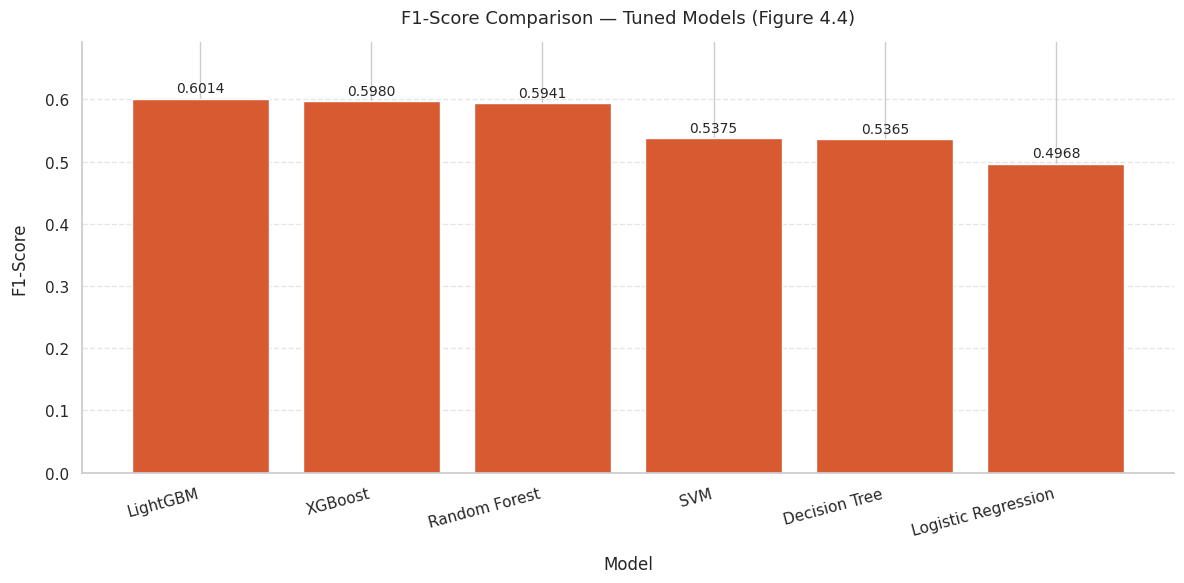

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

f1_tuned = tuned_df['F1-Score'].sort_values(ascending=False)

bars = ax.bar(
    f1_tuned.index,
    f1_tuned.values,
    color=COLOUR_YES,
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=10
    )

plt.title('F1-Score Comparison — Tuned Models (Figure 4.4)', pad=14, fontsize=13)
plt.xlabel('Model', labelpad=12)
plt.ylabel('F1-Score', labelpad=12)
plt.ylim(0, f1_tuned.max() * 1.15)
plt.xticks(rotation=15, ha='right')
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_4_4_tuned_f1_comparison.png', dpi=300)
plt.show()

print('\n')

## Cell 34 — Tuned ROC-AUC Curves (Figure 4.3)

ROC curves for all six tuned models. Compare with Figure 4.1 to see how much tuning improved discriminative ability.

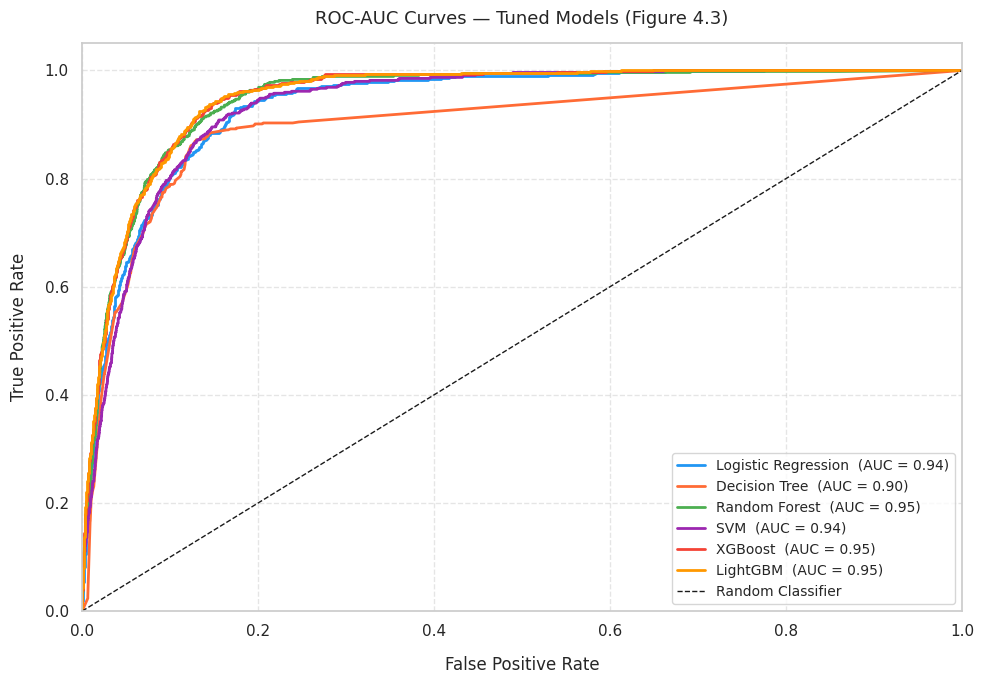

In [38]:
fig, ax = plt.subplots(figsize=(10, 7))

for (name, data), colour in zip(tuned_roc.items(), colours_roc):
    ax.plot(
        data['fpr'], data['tpr'],
        label=f"{name}  (AUC = {data['auc']:.2f})",
        color=colour, linewidth=2
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.title(
    'ROC-AUC Curves — Tuned Models (Figure 4.3)',
    pad=14, fontsize=13
)
plt.xlabel('False Positive Rate', labelpad=12)
plt.ylabel('True Positive Rate', labelpad=12)
plt.legend(loc='lower right', fontsize=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_4_3_tuned_roc_curves.png', dpi=300)
plt.show()

print('\n')

## Cell 35 — Tuned Confusion Matrices

Confusion matrices for all six tuned models. Compare with Cell 31 to see how tuning changed the True Positive and False Negative counts for each model.

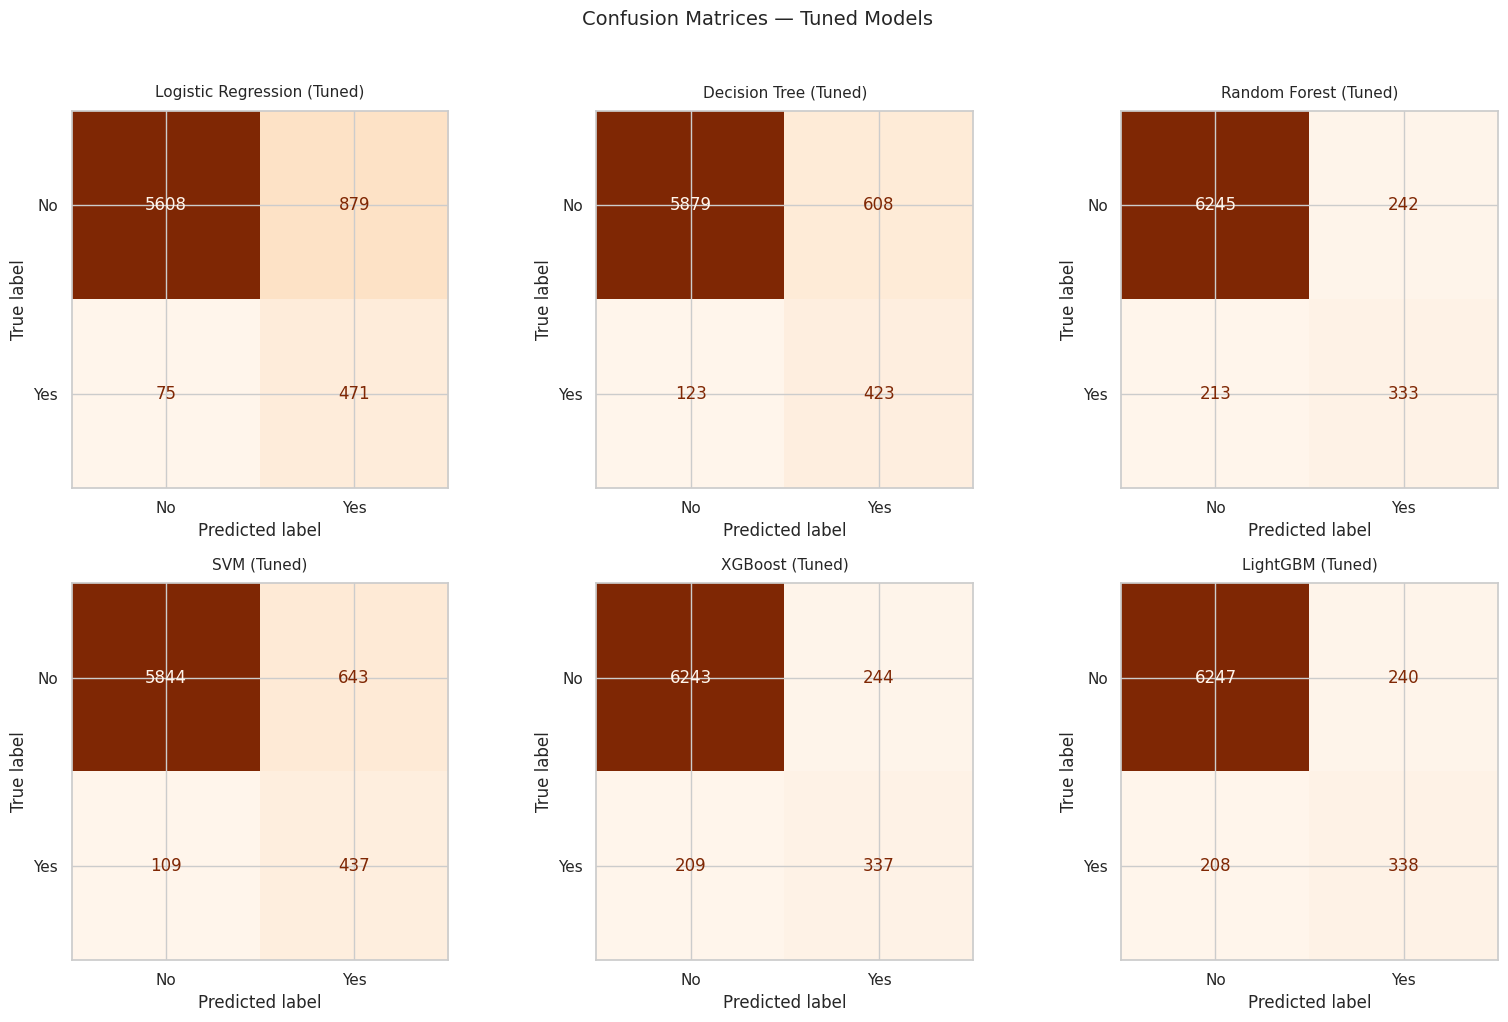

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, estimator) in enumerate(best_estimators.items()):
    y_pred = estimator.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Oranges')
    axes[idx].set_title(f'{name} (Tuned)', fontsize=11, pad=10)

plt.suptitle(
    'Confusion Matrices — Tuned Models',
    fontsize=14, y=1.02, fontweight='medium'
)
plt.tight_layout()
plt.savefig('fig_tuned_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n')

## Cell 36 — Best Hyperparameters Found (Table 4.3)

The optimal parameter configuration identified by RandomizedSearchCV for each model. This becomes Table 4.3 in the report.

In [40]:
print('Best Hyperparameters Found — Table 4.3')
print('=' * 65)

for name, params in best_params.items():
    print(f'\n{name}:')
    for param, value in params.items():
        # Strip the 'model__' prefix for cleaner output
        clean_param = param.replace('model__', '')
        print(f'  {clean_param:<25} : {value}')

Best Hyperparameters Found — Table 4.3

Logistic Regression:
  solver                    : saga
  penalty                   : l2
  C                         : 1

Decision Tree:
  min_samples_split         : 2
  max_depth                 : 10
  criterion                 : gini

Random Forest:
  n_estimators              : 300
  max_features              : log2
  max_depth                 : 20

SVM:
  kernel                    : rbf
  gamma                     : scale
  C                         : 10

XGBoost:
  n_estimators              : 100
  max_depth                 : 5
  learning_rate             : 0.1

LightGBM:
  num_leaves                : 63
  n_estimators              : 200
  max_depth                 : 5
  learning_rate             : 0.05


## Cell 37 — Feature Importance Extraction

Feature importance is extracted from the five tree-based models. SVM does not have a direct feature importance method so it is excluded. These charts feed into Section 5.2 (Feature Importance and Key Predictors) in the Discussion chapter.

In [1]:
importance_models = {
    k: v for k, v in best_estimators.items()
    if k not in ['SVM', 'Logistic Regression']
}

for name, estimator in importance_models.items():

    # Extract the trained model from inside the pipeline
    trained_model = estimator.named_steps['model']

    # Get feature importances
    importances = trained_model.feature_importances_

    # Get feature names after transformation
    try:
        preprocessor_fitted = estimator.named_steps['preprocessor']
        feature_names_out = preprocessor_fitted.get_feature_names_out()
    except Exception:
        feature_names_out = [f'feature_{i}' for i in range(len(importances))]

    # Build importance DataFrame and take top 15
    imp_df = pd.DataFrame({
        'Feature'   : feature_names_out,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=imp_df,
        x='Importance',
        y='Feature',
        color=COLOUR_NO,
        ax=ax
    )
    plt.title(f'Feature Importance — {name}', pad=14, fontsize=13)
    plt.xlabel('Importance', labelpad=12)
    plt.ylabel('Feature', labelpad=12)
    sns.despine(top=True, right=True)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()

    filename = f"fig_feature_importance_{name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    plt.show()

    print('\n')

NameError: name 'best_estimators' is not defined

## Cell 38 — Before vs After Tuning Comparison

A side-by-side table showing the F1-Score and ROC-AUC for every model before and after tuning. This is one of the most important results tables in the report.

In [ ]:
comparison = pd.DataFrame({
    'Baseline F1'  : baseline_df['F1-Score'],
    'Tuned F1'     : tuned_df['F1-Score'],
    'F1 Change'    : (tuned_df['F1-Score'] - baseline_df['F1-Score']).round(4),
    'Baseline AUC' : baseline_df['ROC-AUC'],
    'Tuned AUC'    : tuned_df['ROC-AUC'],
    'AUC Change'   : (tuned_df['ROC-AUC'] - baseline_df['ROC-AUC']).round(4),
    'Baseline MCC' : baseline_df['MCC'],
    'Tuned MCC'    : tuned_df['MCC'],
    'MCC Change'   : (tuned_df['MCC'] - baseline_df['MCC']).round(4)
})

print('Before vs After Tuning — Full Comparison')
print('=' * 75)
print(comparison.to_string())

## Cell 39 — Download All Charts

Run this final cell to download every saved chart from Colab at once.